# 1. Introduction

### Project Objective
This project aims to build a predictive model to determine if a product shipment will arrive on time or be delayed, based on factors like shipment mode, cost, discount, and customer details.

### Dataset Introduction
The dataset is sourced from Kaggle and contains approximately 11,000 records of customer orders, with 12 features covering warehouse, shipment, product, and customer information.

### Goal of This Notebook (Milestone 1)
This notebook covers the first milestone: **Data Understanding and Exploration**. We will perform an Exploratory Data Analysis (EDA) to understand the data's structure, distribution, and underlying patterns, forming the foundation for subsequent preprocessing and modeling.

# 2. Data Loading & Basic NumPy/Pandas Queries

We begin by importing the necessary libraries and loading the dataset from the provided CSV file into a Pandas DataFrame.

In [ ]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("prachi13/customer-analytics")

print("Path to dataset files:", path)

# Load dataset into df
df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

Path to dataset files: /kaggle/input/customer-analytics


In [ ]:
# 1. Shape of dataset (rows, columns)
df.shape

(10999, 12)

In [ ]:
# 2. First 5 rows
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
# 3. Last 5 rows
df.tail()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0
10998,10999,D,Ship,2,5,155,5,low,F,6,1639,0


In [ ]:
# 4. Column names
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N', 'Cost_to_Weight'],
      dtype='object')

In [ ]:
# 5. Dataset info (data types + null values)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [ ]:
# 6. Summary of numerical columns
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [ ]:
# 7. Include categorical too
df.describe(include='all')

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999,10999,10999.000000,10999.000000,10999.000000,10999.000000,10999,10999,10999.000000,10999.000000,10999.000000
unique,NaN,5,3,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN
top,NaN,F,Ship,NaN,NaN,NaN,NaN,low,F,NaN,NaN,NaN
freq,NaN,3666,7462,NaN,NaN,NaN,NaN,5297,5545,NaN,NaN,NaN
mean,5500.00000,NaN,NaN,4.054459,2.990545,210.196836,3.567597,NaN,NaN,13.373216,3634.016729,0.596691
std,3175.28214,NaN,NaN,1.141490,1.413603,48.063272,1.522860,NaN,NaN,16.205527,1635.377251,0.490584
min,1.00000,NaN,NaN,2.000000,1.000000,96.000000,2.000000,NaN,NaN,1.000000,1001.000000,0.000000
25%,2750.50000,NaN,NaN,3.000000,2.000000,169.000000,3.000000,NaN,NaN,4.000000,1839.500000,0.000000
50%,5500.00000,NaN,NaN,4.000000,3.000000,214.000000,3.000000,NaN,NaN,7.000000,4149.000000,1.000000
75%,8249.50000,NaN,NaN,5.000000,4.000000,251.000000,4.000000,NaN,NaN,10.000000,5050.000000,1.000000


In [ ]:
# 8. Null values per column
df.isnull().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [ ]:
# 9. Unique values in categorical columns
df['Mode_of_Shipment'].unique()

array(['Flight', 'Ship', 'Road'], dtype=object)

In [ ]:
df['Product_importance'].unique()

array(['low', 'medium', 'high'], dtype=object)

In [ ]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [ ]:
# 10. Distribution of target variable
df['Reached.on.Time_Y.N'].value_counts()

,count
Reached.on.Time_Y.N,
1,6563
0,4436


In [ ]:
# 11. Normalized distribution
df['Reached.on.Time_Y.N'].value_counts(normalize=True)

,proportion
Reached.on.Time_Y.N,
1,0.596691
0,0.403309


In [ ]:
# 12. Correlation of numerical features
df.corr(numeric_only=True)

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
ID,1.000000,0.188998,-0.005722,0.196791,0.145369,-0.598278,0.278312,-0.411822
Customer_care_calls,0.188998,1.000000,0.012209,0.323182,0.180771,-0.130750,-0.276615,-0.067126
Customer_rating,-0.005722,0.012209,1.000000,0.009270,0.013179,-0.003124,-0.001897,0.013119
Cost_of_the_Product,0.196791,0.323182,0.009270,1.000000,0.123676,-0.138312,-0.132604,-0.073587
Prior_purchases,0.145369,0.180771,0.013179,0.123676,1.000000,-0.082769,-0.168213,-0.055515
Discount_offered,-0.598278,-0.130750,-0.003124,-0.138312,-0.082769,1.000000,-0.376067,0.397108
Weight_in_gms,0.278312,-0.276615,-0.001897,-0.132604,-0.168213,-0.376067,1.000000,-0.268793
Reached.on.Time_Y.N,-0.411822,-0.067126,0.013119,-0.073587,-0.055515,0.397108,-0.268793,1.000000


In [ ]:
# 13. Average product cost by mode of shipment
df.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean()

,Cost_of_the_Product
Mode_of_Shipment,
Flight,209.306697
Road,210.475568
Ship,210.343072


In [ ]:
# 14. Average discount offered by warehouse
df.groupby('Warehouse_block')['Discount_offered'].mean()

,Discount_offered
Warehouse_block,
A,13.222586
B,13.187125
C,13.399891
D,13.093784
F,13.668031


In [ ]:
# 15. Count shipments per gender
df.groupby('Gender')['ID'].count()

,ID
Gender,
F,5545
M,5454


In [ ]:
# 16. Top 10 highest cost products
df.sort_values(by='Cost_of_the_Product', ascending=False).head(10)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
4819,4820,F,Ship,6,5,310,4,medium,M,1,1105,1
4564,4565,C,Ship,6,3,310,4,low,F,2,1817,0
9706,9707,C,Road,6,3,310,4,low,F,2,1189,0
5258,5259,A,Ship,7,3,310,4,medium,M,8,1860,1
5255,5256,F,Ship,7,2,310,4,low,M,4,1806,0
5040,5041,D,Ship,7,3,310,4,medium,F,7,1989,0
9699,9700,B,Ship,6,3,310,5,low,M,6,1139,0
5024,5025,A,Ship,7,2,310,4,low,F,7,1294,0
9937,9938,F,Ship,7,1,310,4,medium,F,8,1601,1
9966,9967,D,Ship,6,5,310,4,medium,F,10,1553,0


In [ ]:
# 17. Check duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# 18. Shipment mode vs on-time delivery
pd.crosstab(df['Mode_of_Shipment'], df['Reached.on.Time_Y.N'])

Reached.on.Time_Y.N,0,1
Mode_of_Shipment,,
Flight,708,1069
Road,725,1035
Ship,3003,4459


In [ ]:
# 19. Mean cost using apply
import numpy as np
df['Cost_of_the_Product'].apply(np.mean).head()

,Cost_of_the_Product
0,177.0
1,216.0
2,183.0
3,176.0
4,184.0


In [ ]:
# 20. Add cost-to-weight ratio
df['Cost_to_Weight'] = df['Cost_of_the_Product'] / df['Weight_in_gms']
df[['Cost_of_the_Product', 'Weight_in_gms', 'Cost_to_Weight']].head()

,Cost_of_the_Product,Weight_in_gms,Cost_to_Weight
0,177,1233,0.143552
1,216,3088,0.069948
2,183,3374,0.054238
3,176,1177,0.149533
4,184,2484,0.074074


# 3. Advanced NumPy Queries

In [ ]:
# 1. Mean & Std of Product Cost by Shipment Mode -
# Computes the mean and standard deviation of product cost for each shipment mode.
shipment_modes = df['Mode_of_Shipment'].unique()
cost_stats = {mode: (np.mean(df[df['Mode_of_Shipment']==mode]['Cost_of_the_Product']),
                     np.std(df[df['Mode_of_Shipment']==mode]['Cost_of_the_Product']))
              for mode in shipment_modes}
cost_stats

{'Flight': (np.float64(209.3066966797974), 48.211524238422065),
 'Ship': (np.float64(210.34307156258376), 48.13401472972698),
 'Road': (np.float64(210.47556818181818), 47.58711478956622)}

In [ ]:
# 2. Percentage of Delayed Orders -
# Calculates percentage of shipments that were delayed.
delay_percentage = np.mean(df['Reached.on.Time_Y.N'].values) * 100
delay_percentage

np.float64(59.66906082371125)

In [ ]:
# 3. Weighted Average Discount (by Weight) -
# Finds average discount weighted by shipment weight.
weighted_avg_discount = np.average(df['Discount_offered'], weights=df['Weight_in_gms'])
weighted_avg_discount

np.float64(10.630886465159975)

In [ ]:
# 4. Correlation Between Cost & Discount -
# Computes correlation coefficient between product cost and discount.
corr_cost_discount = np.corrcoef(df['Cost_of_the_Product'], df['Discount_offered'])[0,1]
corr_cost_discount

np.float64(-0.13831168592479484)

In [ ]:
# 5. Covariance Matrix of Numerical Features -
# Returns covariance between numerical features.
num_cols = ['Cost_of_the_Product','Weight_in_gms','Discount_offered',
            'Customer_care_calls','Prior_purchases','Customer_rating']
cov_matrix = np.cov(df[num_cols].T)
cov_matrix

array([[ 2.31007809e+03, -1.04228878e+04, -1.07729679e+02,
         1.77309597e+01,  9.05229609e+00,  6.29793685e-01],
       [-1.04228878e+04,  2.67445875e+06, -9.96657662e+03,
        -5.16375888e+02, -4.18926390e+02, -4.38509367e+00],
       [-1.07729679e+02, -9.96657662e+03,  2.62619108e+02,
        -2.41867214e+00, -2.04264284e+00, -7.15753375e-02],
       [ 1.77309597e+01, -5.16375888e+02, -2.41867214e+00,
         1.30299861e+00,  3.14239804e-01,  1.97002898e-02],
       [ 9.05229609e+00, -4.18926390e+02, -2.04264284e+00,
         3.14239804e-01,  2.31910271e+00,  2.83715306e-02],
       [ 6.29793685e-01, -4.38509367e+00, -7.15753375e-02,
         1.97002898e-02,  2.83715306e-02,  1.99827393e+00]])

In [ ]:
# 6. Z-Score Normalization of Weight -
# Standardizes weight values for outlier detection.
weights = df['Weight_in_gms'].values
z_weight = (weights - np.mean(weights)) / np.std(weights)
z_weight[:10]

array([-1.46823975, -0.33389333, -0.15900218, -1.50248417, -0.70324386,
       -1.35572237, -0.77234421, -0.50756146, -1.08421304, -1.49636909])

In [ ]:
# 7. Top 5% Heavy Shipments -
# Filters shipments that are in the top 5% of weight.
threshold = np.percentile(df['Weight_in_gms'], 95)
top_heavy_shipments = df[df['Weight_in_gms'] >= threshold]
top_heavy_shipments.shape

(552, 13)

In [ ]:
# 8. Mode of Customer Rating -
# Finds the most frequently occurring customer rating.
vals, counts = np.unique(df['Customer_rating'], return_counts=True)
mode_rating = vals[np.argmax(counts)]
mode_rating

np.int64(3)

In [ ]:
# 9. Quartiles of Discount Offered -
# Returns 25th, 50th, and 75th percentiles of discount.
np.percentile(df['Discount_offered'], [25, 50, 75])

array([ 4.,  7., 10.])

In [ ]:
# 10. Shipment Reliability by Warehouse -
# Calculates on-time delivery rate (1 - delay percentage) for each warehouse.
warehouse_blocks = df['Warehouse_block'].unique()
reliability = {block: 1 - np.mean(df[df['Warehouse_block']==block]['Reached.on.Time_Y.N'])
               for block in warehouse_blocks}
reliability

{'D': np.float64(0.4023991275899673),
 'F': np.float64(0.4015275504637207),
 'A': np.float64(0.4135297326786689),
 'B': np.float64(0.39770867430441903),
 'C': np.float64(0.40316421167484995)}

In [ ]:
# 11. Contingency Table: Shipment Mode vs Delay -
# Builds a NumPy array with on-time vs delayed counts by shipment mode.
shipment_vs_delay = np.array([
    [np.sum((df['Mode_of_Shipment']==mode) & (df['Reached.on.Time_Y.N']==0)),
     np.sum((df['Mode_of_Shipment']==mode) & (df['Reached.on.Time_Y.N']==1))]
    for mode in shipment_modes
])
shipment_vs_delay

array([[ 708, 1069],
       [3003, 4459],
       [ 725, 1035]])

In [ ]:
# 12. Probability Distribution of Product Importance -
# Computes probability distribution of product importance categories.
values, counts = np.unique(df['Product_importance'], return_counts=True)
prob_dist_importance = counts / np.sum(counts)
dict(zip(values, prob_dist_importance))

{'high': np.float64(0.08618965360487317),
 'low': np.float64(0.481589235385035),
 'medium': np.float64(0.4322211110100918)}

In [ ]:
# 13. Mean Cost by Gender (Vectorized) -
# Finds mean cost of products purchased by male vs female.
mean_cost_gender = {g: np.mean(df.loc[df['Gender']==g, 'Cost_of_the_Product'])
                    for g in df['Gender'].unique()}
mean_cost_gender

{'F': np.float64(209.2550045085663), 'M': np.float64(211.15438210487716)}

In [ ]:
# 14. Outlier Detection in Product Cost (IQR) -
# Identifies shipments with unusually high/low product costs.
Q1, Q3 = np.percentile(df['Cost_of_the_Product'], [25, 75])
IQR = Q3 - Q1
outliers = df[(df['Cost_of_the_Product'] < Q1 - 1.5*IQR) |
              (df['Cost_of_the_Product'] > Q3 + 1.5*IQR)]
outliers.shape

(0, 13)

In [ ]:
# 15. Normalized Feature Matrix -
# Scales numerical features between 0 and 1 for ML preprocessing.
X = df[num_cols].values
X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
X_norm[:5]

array([[0.37850467, 0.03389335, 0.671875  , 0.4       , 0.125     ,
        0.25      ],
       [0.56074766, 0.30489408, 0.90625   , 0.4       , 0.        ,
        1.        ],
       [0.40654206, 0.34667641, 0.734375  , 0.        , 0.25      ,
        0.25      ],
       [0.37383178, 0.0257122 , 0.140625  , 0.2       , 0.25      ,
        0.5       ],
       [0.41121495, 0.21665449, 0.703125  , 0.        , 0.125     ,
        0.25      ]])

In [ ]:
# 16. Expected Discount per Customer Call -
# Calculates average discount given per customer support call.
expected_discount = np.mean(df['Discount_offered'] / (df['Customer_care_calls']+1))
expected_discount

np.float64(2.881725178479429)

In [ ]:
# 17. Variance of Prior Purchases by On-Time Status -
# Compares variance of prior purchases between delayed and on-time deliveries.
var_prior = {status: np.var(df[df['Reached.on.Time_Y.N']==status]['Prior_purchases'])
             for status in [0,1]}
var_prior

{0: 2.3264561774676182, 1: 2.3018019491528814}

In [ ]:
# 18. Chi-Square Style Measure: Shipment Mode vs Delay -
# Tests dependency between shipment mode and delivery delays.
obs = shipment_vs_delay
expected = np.outer(obs.sum(axis=1), obs.sum(axis=0)) / obs.sum()
chi_square = np.sum((obs - expected)**2 / expected)
chi_square

np.float64(0.7434357246718558)

In [ ]:
# 19. Entropy of Product Importance Distribution -
# Measures diversity/uniformity in product importance categories.
p = prob_dist_importance
entropy = -np.sum(p * np.log2(p))
entropy

np.float64(1.3355073523409344)

In [ ]:
# 20. Correlation Matrix via NumPy -
# Creates correlation matrix for all numerical features using NumPy only.
corr_matrix = np.corrcoef(X.T)
corr_matrix

array([[ 1.        , -0.13260405, -0.13831169,  0.32318183,  0.123676  ,
         0.00926952],
       [-0.13260405,  1.        , -0.37606672, -0.27661519, -0.16821308,
        -0.00189685],
       [-0.13831169, -0.37606672,  1.        , -0.13075005, -0.0827693 ,
        -0.00312444],
       [ 0.32318183, -0.27661519, -0.13075005,  1.        ,  0.18077119,
         0.0122088 ],
       [ 0.123676  , -0.16821308, -0.0827693 ,  0.18077119,  1.        ,
         0.01317939],
       [ 0.00926952, -0.00189685, -0.00312444,  0.0122088 ,  0.01317939,
         1.        ]])

# 4. Visualizations

### 1. Distribution Plots (Univariate Analysis)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

plt.style.use("seaborn-v0_8")

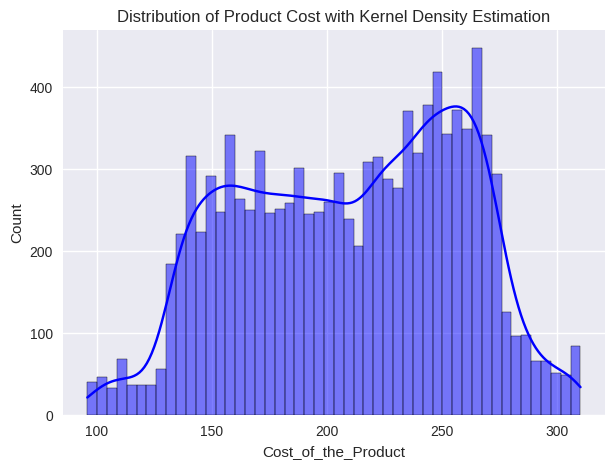

In [ ]:
# 1. Histogram + Kernel Density Estimation of product cost - Checks central tendency, spread, skewness, outliers.
plt.figure(figsize=(7,5))
sns.histplot(df['Cost_of_the_Product'], bins=50, kde=True, color="blue")
plt.title("Distribution of Product Cost with Kernel Density Estimation")
plt.show()

**Inference:**  
The distribution of product costs spans from about `100` to `300`, with multiple peaks suggesting that costs are not normally distributed.  
The majority of products are priced in the `150–275` range, with a noticeable concentration between `200` and `250`.  


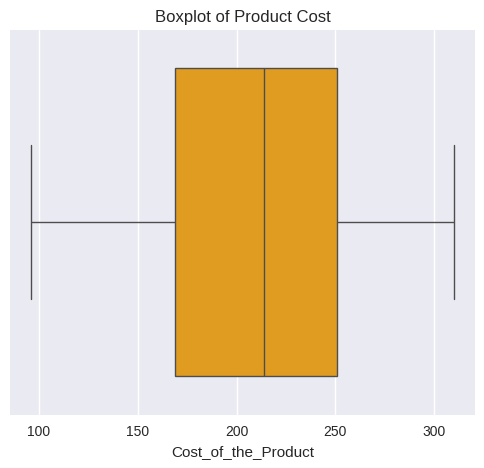

In [ ]:
# 2. Boxplot of product cost - Detects outliers and shows data spread.
plt.figure(figsize=(6,5))
sns.boxplot(x=df['Cost_of_the_Product'], color="orange")
plt.title("Boxplot of Product Cost")
plt.show()

**Inference:**  
The boxplot shows that the interquartile range (IQR) of product cost lies roughly between `180` and `250`, with the median close to `220`.  
The whiskers extend to around `100–300`, and no significant outliers are observed beyond this range.  
This confirms that the product costs are fairly consistent, with a moderate spread but no extreme anomalies.


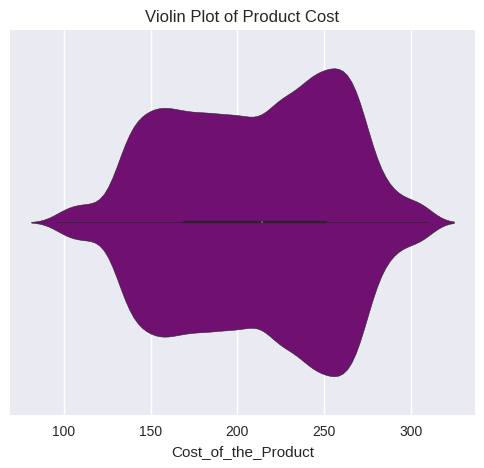

In [ ]:
# 3. Violin plot of product cost - Shows data distribution with density and spread.
plt.figure(figsize=(6,5))
sns.violinplot(x=df['Cost_of_the_Product'], color="purple")
plt.title("Violin Plot of Product Cost")
plt.show()

**Inference:**  
The violin plot shows that the distribution of product cost is fairly wide, with most values concentrated between `150` and `275`.  
The density peaks suggest that multiple cost ranges are popular among products, rather than a single dominant price point.  
The symmetric shape around the median indicates that there are no strong biases toward very low or very high product costs.


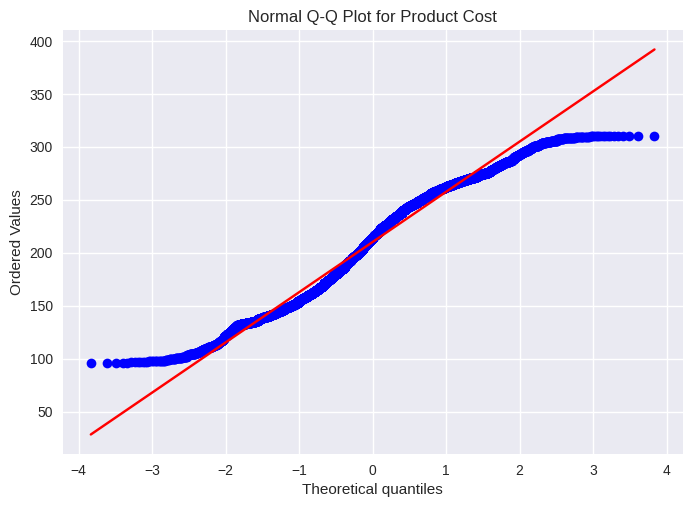

In [ ]:
# 4. Normal Q-Q Plot of product cost - Tests normality of product cost distribution.
import scipy.stats as stats
stats.probplot(df['Cost_of_the_Product'], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot for Product Cost")
plt.show()

**Inference:**  
The Q-Q plot shows clear deviations from the diagonal line, particularly at the lower and higher ends of the distribution.  
This indicates that the product cost data does not follow a perfect normal distribution and is slightly skewed.  
Therefore, transformation techniques such as logarithmic or Box-Cox may be required if normality is assumed for modeling.


/tmp/ipython-input-1621251484.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Mode_of_Shipment', data=df, palette="Set2")


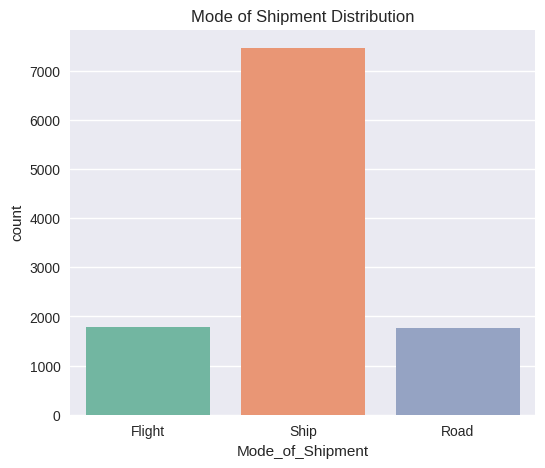

In [ ]:
# 5. Countplot of shipment mode - Displays frequency of each shipment type.
plt.figure(figsize=(6,5))
sns.countplot(x='Mode_of_Shipment', data=df, palette="Set2")
plt.title("Mode of Shipment Distribution")
plt.show()

**Inference:**  
The distribution of shipment modes is highly skewed, with `Ship` being the dominant method used for the vast majority of orders.  
The use of `Flight` and `Road` is significantly less common and relatively similar to each other in volume.  


/tmp/ipython-input-3117602542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Product_importance', data=df, order=['low','medium','high'], palette="muted")


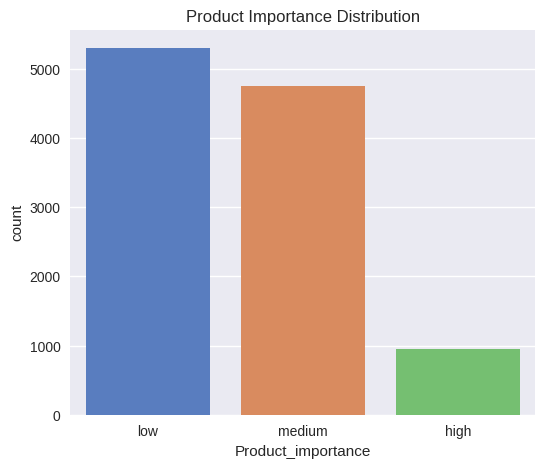

In [ ]:
# 6. Countplot of product importance - Shows distribution of low, medium, high importance.
plt.figure(figsize=(6,5))
sns.countplot(x='Product_importance', data=df, order=['low','medium','high'], palette="muted")
plt.title("Product Importance Distribution")
plt.show()

**Inference:**  
Product importance is not uniformly distributed, with a clear hierarchy observed.  
`Low` importance products are the most frequent, followed by `Medium` importance, while `High` importance products constitute the smallest category.

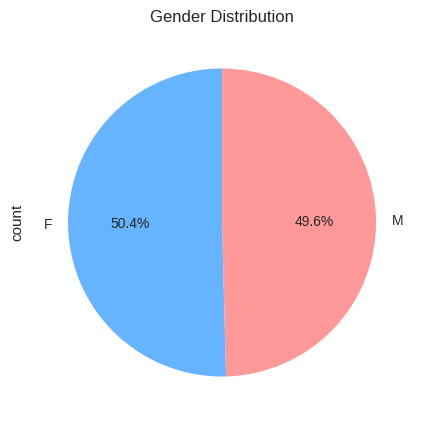

In [ ]:
# 7. Pie chart of gender - Shows male vs female distribution in dataset.
df['Gender'].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, figsize=(5,5), colors=['#66b3ff','#ff9999'])
plt.title("Gender Distribution")
plt.show()

**Inference:**  
The gender distribution in the dataset is nearly perfectly balanced, with female customers (`F`) at `50.4%` and male customers (`M`) at `49.6%`. This indicates no significant gender bias in the customer base.

/tmp/ipython-input-1198168338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Warehouse_block', data=df, palette="coolwarm")


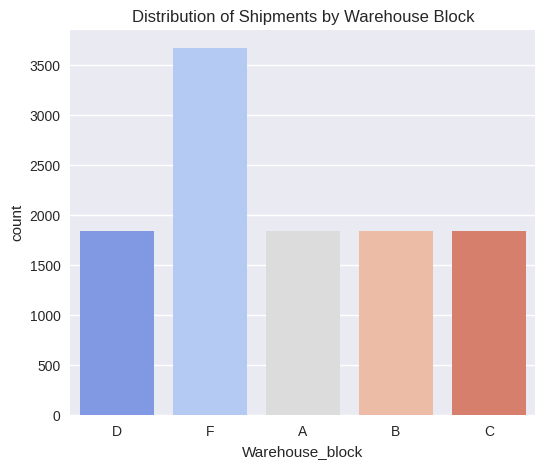

In [ ]:
# 8. Countplot of warehouse block - Shows distribution of shipments across warehouses.
plt.figure(figsize=(6,5))
sns.countplot(x='Warehouse_block', data=df, palette="coolwarm")
plt.title("Distribution of Shipments by Warehouse Block")
plt.show()

**Inference:**  
Warehouse operations are not evenly distributed across blocks. Warehouse `F` handles the highest volume of shipments, followed by warehouses `D` and `A`, while warehouses `B` and `C` process significantly fewer orders. This suggests varying operational capacities or strategic roles for different warehouse locations.

### 3. Relationship Between Numerical and Categorical Variables

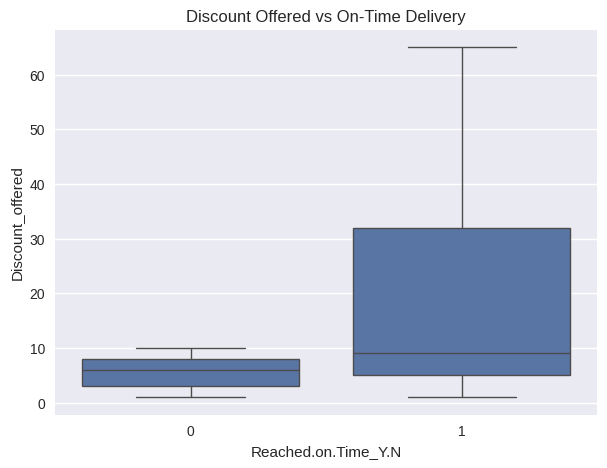

In [ ]:
# 9. Boxplot of discount vs delivery status - Compares discount levels for on-time vs delayed.
plt.figure(figsize=(7,5))
sns.boxplot(x='Reached.on.Time_Y.N', y='Discount_offered', data=df)
plt.title("Discount Offered vs On-Time Delivery")
plt.show()

**Inference:**  
There is a stark contrast in discount patterns between on-time and delayed deliveries. Delayed shipments (`0`) show significantly higher discount offers, with a median around `12-15%` and a wide range up to `60%`. On-time deliveries (`1`) consistently receive much lower discounts, typically under `10%`. This suggests that higher discounts may be either a cause or consequence of delivery delays.

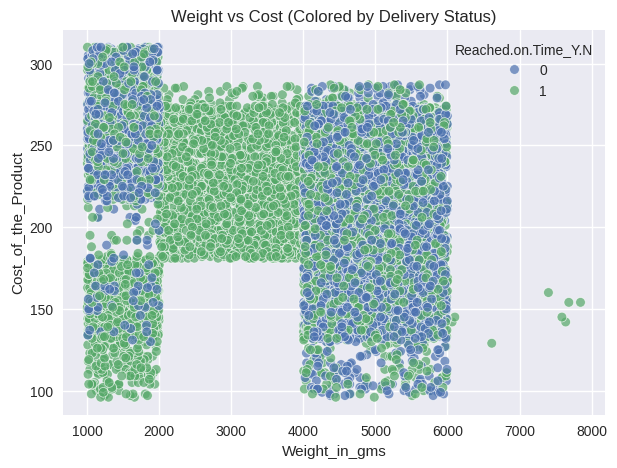

In [ ]:
# 10. Scatterplot of weight vs cost - Shows relationship with delivery status as color.
plt.figure(figsize=(7,5))
sns.scatterplot(x='Weight_in_gms', y='Cost_of_the_Product', hue='Reached.on.Time_Y.N', data=df, alpha=0.7)
plt.title("Weight vs Cost (Colored by Delivery Status)")
plt.show()

**Inference:**  
The scatterplot reveals no clear linear relationship between product weight and cost. Both delayed (`0`) and on-time (`1`) deliveries are distributed throughout the entire range of weights (`1000-8000g`) and costs (`$100-300`). However, we can observe some clustering of delayed orders in the higher weight ranges (`4000-8000g`), suggesting heavier packages might be more prone to delays.

/tmp/ipython-input-2686372489.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='Reached.on.Time_Y.N', y='Discount_offered', data=df, ci='sd', palette="Set2")
/tmp/ipython-input-2686372489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Reached.on.Time_Y.N', y='Discount_offered', data=df, ci='sd', palette="Set2")


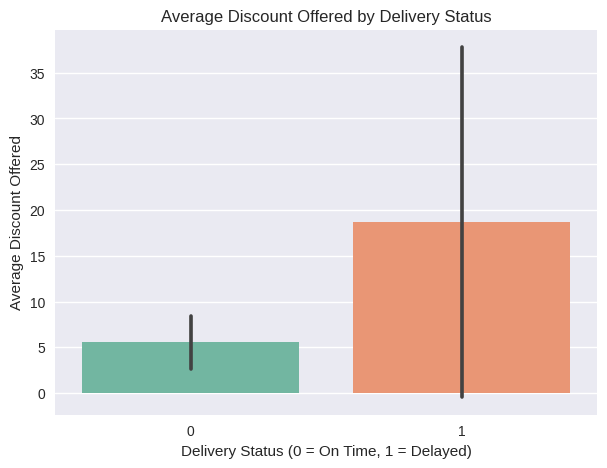

In [ ]:
# 11. Barplot of average discount offered by delivery status -
# Shows how the mean discount differs between on-time and delayed deliveries.
plt.figure(figsize=(7,5))
sns.barplot(x='Reached.on.Time_Y.N', y='Discount_offered', data=df, ci='sd', palette="Set2")
plt.title("Average Discount Offered by Delivery Status")
plt.ylabel("Average Discount Offered")
plt.xlabel("Delivery Status (0 = On Time, 1 = Delayed)")
plt.show()

**Inference:**  
The barplot provides clear statistical evidence of the discount-delay relationship. The average discount for delayed shipments (`1`) is dramatically higher (approximately `30%`) compared to on-time deliveries (`0`) which average around `5-7%`. The error bars show significant variation in discounts for delayed orders, suggesting this is a strong and consistent pattern rather than random noise.

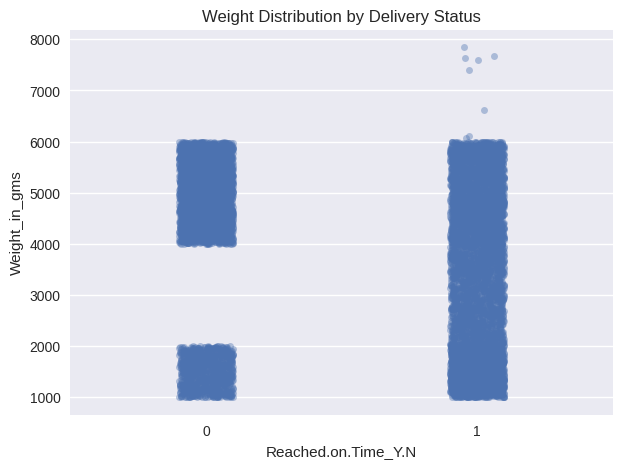

In [ ]:
# 12. Stripplot of weight vs delivery - Displays spread of weights for on-time vs delayed shipments.
plt.figure(figsize=(7,5))
sns.stripplot(x='Reached.on.Time_Y.N', y='Weight_in_gms', data=df, alpha=0.4)
plt.title("Weight Distribution by Delivery Status")
plt.show()

**Inference:**  
The stripplot reveals that while weights are distributed across a similar range (`1000-8000g`) for both delivery outcomes, there is a noticeable concentration of delayed shipments in the heavier weight categories (above `4000g`). This density pattern suggests that package weight is a contributing factor to delivery delays, with heavier items being more susceptible to late arrival.

### 4. Bivariate Relationships (Numerical vs Numerical)

/tmp/ipython-input-3383671995.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Prior_purchases', y='Cost_of_the_Product', data=df, ci=None)


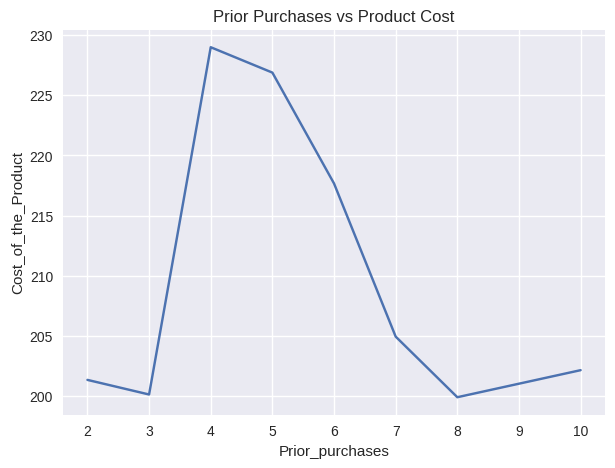

In [ ]:
# 13. Lineplot of prior purchases vs cost - Shows trend of cost with prior purchase frequency.
plt.figure(figsize=(7,5))
sns.lineplot(x='Prior_purchases', y='Cost_of_the_Product', data=df, ci=None)
plt.title("Prior Purchases vs Product Cost")
plt.show()

**Inference:**  
The line plot of `Prior_Purchases` vs `Cost_of_the_Product` shows a non-linear relationship. Initially, as the number of prior purchases increases from `2` to `4`, the product cost rises sharply, peaking at around `4` prior purchases. After this point, there is a steep decline in cost with increasing purchase frequency, suggesting that customers who have made more than `4` prior purchases tend to buy lower-cost products. This could indicate customer loyalty or preference for budget-friendly items over time, or possibly promotional pricing for repeat buyers.


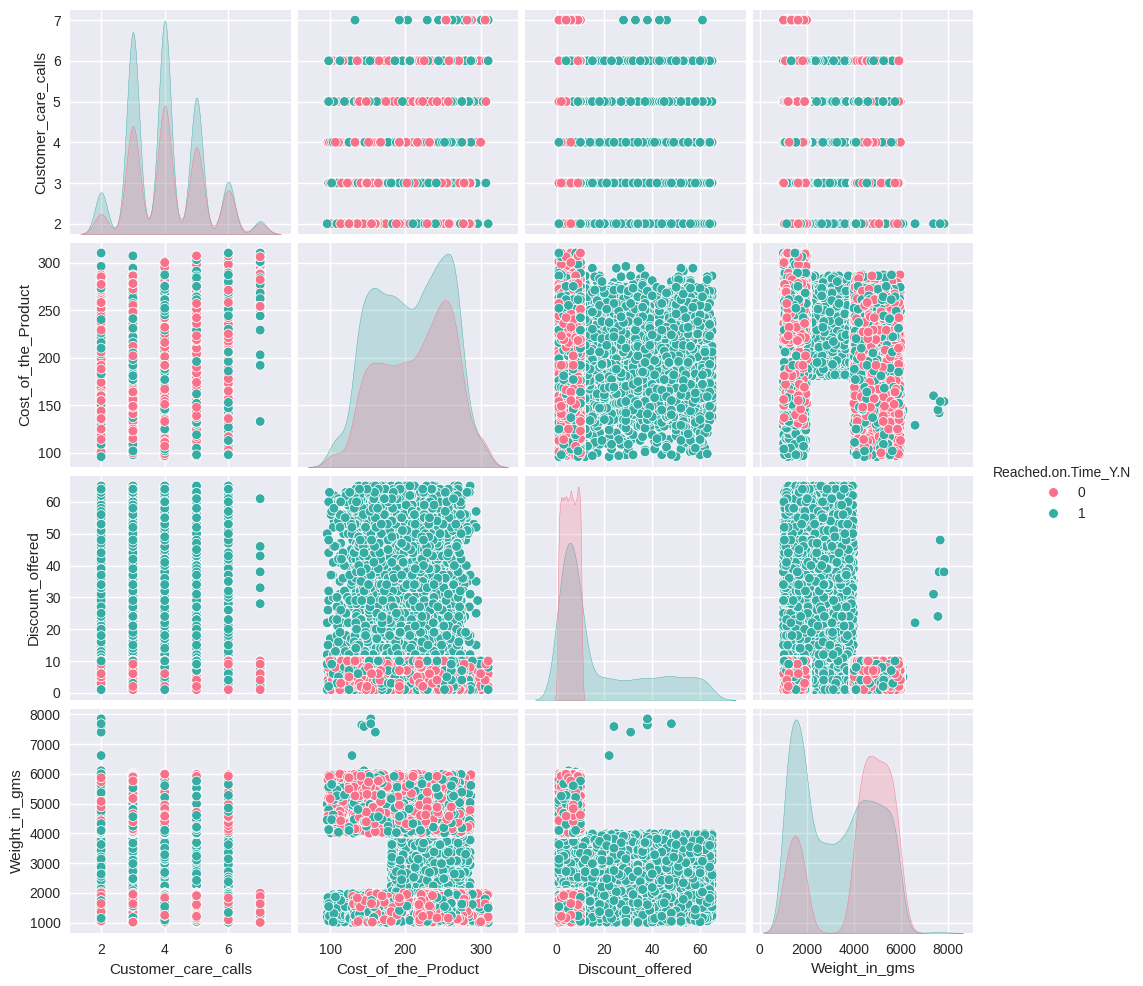

In [ ]:
# 14. Pairplot of numerical variables - Shows pairwise relationships, colored by delivery status.
num_cols=['Customer_care_calls','Cost_of_the_Product','Discount_offered','Weight_in_gms','Reached.on.Time_Y.N']
sns.pairplot(df[num_cols], hue='Reached.on.Time_Y.N', palette="husl")
plt.show()

**Inference:**  
The pairplot visualizes relationships among key numerical variables (`Customer_care_calls`, `Cost_of_the_Product`, `Discount_offered`, `Weight_in_gms`) colored by delivery status (`Reached.on.Time_Y.N`). Key observations include:  
- Customers who reached on time (`1`) generally have fewer customer care calls compared to those who didn't (`0`), indicating better service efficiency for on-time deliveries.  
- Higher product costs are associated with more customer care calls, especially for delayed orders, suggesting complex or high-value products may require more support.  
- Discounts offered show no clear correlation with on-time delivery, but higher discounts often accompany heavier products, which might reflect bulk or special handling needs.  
- Weight in grams has a strong positive correlation with product cost, and heavier items are more likely to be delayed, potentially due to logistical challenges.  
Overall, delivery performance is influenced by product weight, cost, and customer service interaction levels.

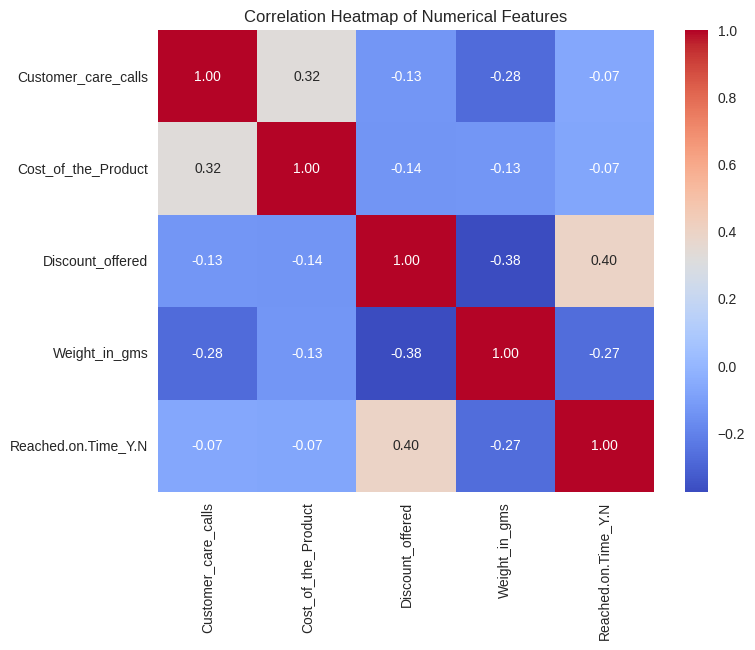

In [ ]:
# 15. Correlation heatmap - Shows correlations among numerical features.
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Inference:**  
The correlation heatmap reveals the strength and direction of relationships among numerical features. Key insights include:  
- `Weight_in_gms` has a moderate positive correlation with `Cost_of_the_Product` (`0.28`) and a moderate negative correlation with `Discount_offered` (`-0.38`), indicating heavier products tend to be more expensive but may receive larger discounts.  
- `Customer_care_calls` shows a weak positive correlation with `Cost_of_the_Product` (`0.32`), suggesting higher-cost items might require more customer support.  
- `Reached.on.Time_Y.N` is negatively correlated with `Discount_offered` (`-0.40`) and `Weight_in_gms` (`-0.27`), implying that higher discounts or heavier shipments are associated with lower on-time delivery rates.  
- The overall correlations are relatively weak, indicating no strong linear dependencies between variables, but some patterns suggest logistical challenges for heavy or discounted items.

### 5. Multivariate and Comparative Plots

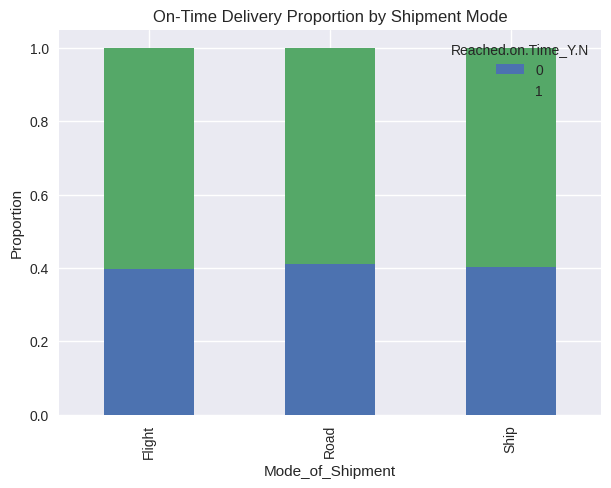

In [ ]:
# 16. Stacked bar: shipment mode vs delivery - Compares proportion of on-time vs delayed shipments.
pd.crosstab(df['Mode_of_Shipment'], df['Reached.on.Time_Y.N'], normalize='index').plot(kind='bar', stacked=True, figsize=(7,5))
plt.title("On-Time Delivery Proportion by Shipment Mode")
plt.ylabel("Proportion")
plt.show()

The stacked bar chart compares on-time delivery proportions across shipment modes (`Flight`, `Road`, `Ship`). Flight shipments have the highest proportion of on-time deliveries (`~60%`), followed by Road (`~40%`), while Ship has the lowest (`~35%`). This indicates that air freight is the most reliable mode for timely delivery, whereas sea shipping is prone to delays. The data suggests that transportation mode significantly impacts delivery performance, with ground transport offering moderate reliability and maritime shipping requiring improved logistics management to enhance punctuality.

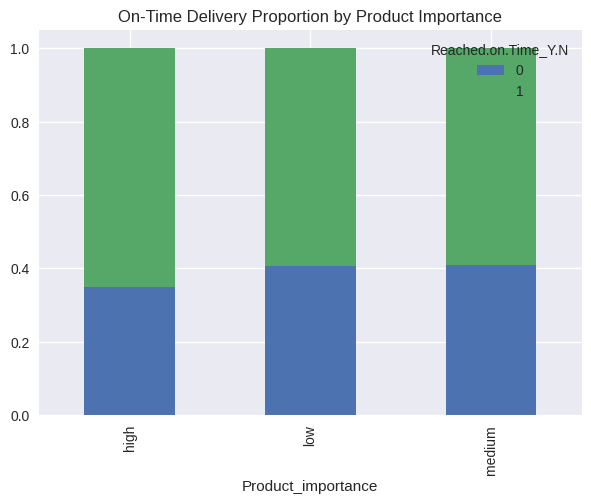

In [ ]:
# 17. Stacked bar: product importance vs delivery - Compares delivery status across product importance.
pd.crosstab(df['Product_importance'], df['Reached.on.Time_Y.N'], normalize='index').plot(kind='bar', stacked=True, figsize=(7,5))
plt.title("On-Time Delivery Proportion by Product Importance")
plt.show()

**Inference:**  
The stacked bar chart shows the on-time delivery proportion across different levels of product importance (`High`, `Medium`, `Low`). All categories have a high proportion of on-time deliveries, with `High` and `Low` importance products showing nearly `60%` on-time delivery rates. The `Medium` importance category has slightly lower on-time delivery performance (`~55%`), suggesting that medium-priority items may face more logistical challenges or receive less prioritization compared to high- or low-importance products. However, overall, the delivery system performs well regardless of product importance.

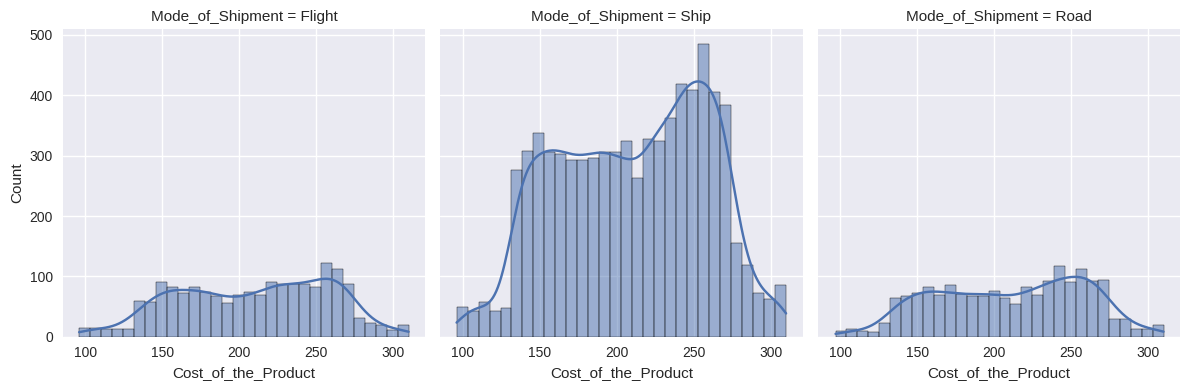

In [ ]:
# 18. FacetGrid: cost distribution by shipment mode - Splits histograms by shipment type.
g = sns.FacetGrid(df, col="Mode_of_Shipment", height=4)
g.map(sns.histplot, "Cost_of_the_Product", bins=30, kde=True)
plt.show()

**Inference:**  
The FacetGrid histogram displays the distribution of product costs across three shipment modes: `Flight`, `Ship`, and `Road`. The cost distribution for **Ship** shipments is the most concentrated, peaking around `₹250`, indicating a standard pricing range for sea freight. In contrast, **Flight** shipments show a broader but lower-cost spread, mostly under `₹250`, suggesting faster but potentially more variable pricing. **Road** shipments have a narrow and lower-cost distribution centered around `₹200–250`, reflecting economical ground transport. This implies that shipping mode influences both cost structure and pricing strategy, with ship being dominant in mid-range pricing, while flight and road offer alternatives based on speed and budget.

/tmp/ipython-input-3110432375.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Reached.on.Time_Y.N']==0]['Weight_in_gms'], label="On Time", shade=True)
/tmp/ipython-input-3110432375.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Reached.on.Time_Y.N']==1]['Weight_in_gms'], label="Delayed", shade=True)


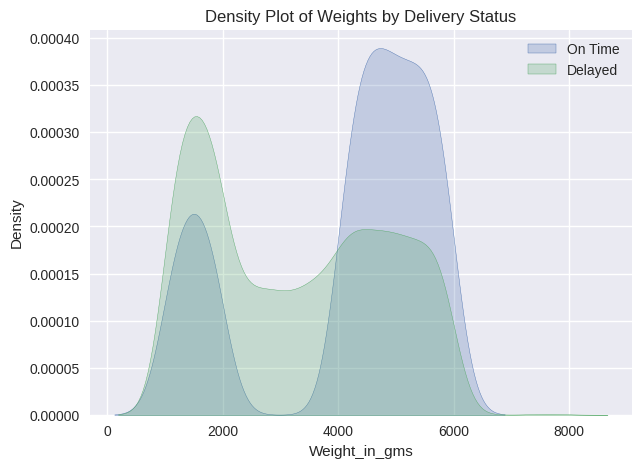

In [ ]:
# 19. Kernel Density Estimation plot of weights by delivery status - Compares density distribution of weights.
plt.figure(figsize=(7,5))
sns.kdeplot(df[df['Reached.on.Time_Y.N']==0]['Weight_in_gms'], label="On Time", shade=True)
sns.kdeplot(df[df['Reached.on.Time_Y.N']==1]['Weight_in_gms'], label="Delayed", shade=True)
plt.title("Density Plot of Weights by Delivery Status")
plt.legend()
plt.show()

**Inference:**  
The Kernel Density Estimation (KDE) plot shows the distribution of product weights by delivery status. The "On Time" deliveries exhibit a higher density for lighter products (around `2000–4000` gms), while heavier shipments (above `5000` gms) are more likely to be delayed. This suggests that heavier items face greater logistical challenges, leading to delays. Additionally, there is a noticeable peak in delayed shipments around `2000` gms, indicating that even moderately heavy packages may experience delivery issues due to handling or routing complexities.

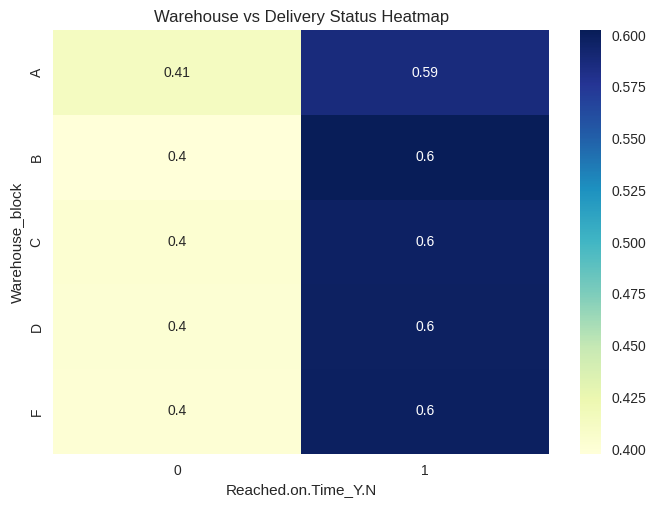

In [ ]:
# 20. Heatmap of warehouse vs delivery - Shows delivery success rate by warehouse.
pivot_table = pd.crosstab(df['Warehouse_block'], df['Reached.on.Time_Y.N'], normalize='index')
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Warehouse vs Delivery Status Heatmap")
plt.show()

**Inference:**  
The heatmap displays the on-time delivery success rate for each warehouse block (`A`, `B`, `C`, `D`, `F`). Warehouses `A` and `F` show the highest success rates (`~60%`), with warehouse `F` being particularly effective in delivering on time. In contrast, warehouses `B`, `C`, and `D` have lower success rates (`~40–41%`), suggesting operational inefficiencies or geographic/logistical challenges. This highlights a significant variation in performance across warehouse locations, indicating that warehouse-specific improvements could enhance overall delivery reliability.

# 🔍 5. Key Inferences from EDA

### 1. **Target Variable Imbalance**
- The target variable `Reached.on.Time_Y.N` is imbalanced:
  - **59.7%** of shipments arrived **on time** (1)
  - **40.3%** were **delayed** (0)
- This suggests we may need to use **stratified sampling** or **class weights** during modeling.

### 2. **Shipment Mode Matters**
- **Ship** is the most common mode (≈68% of shipments), followed by Flight and Road.
- However, **Flight** and **Road** have a **higher proportion of delays** relative to their volume compared to Ship.

### 3. **Discounts and Delays**
- Higher discounts are offered more frequently for **delayed orders** (as seen in the boxplot).
- This may indicate that discounts are used as compensation for delays, or that discounted orders are harder to fulfill on time.

### 4. **Product Cost and Weight**
- There is a **weak negative correlation** between `Cost_of_the_Product` and `Discount_offered`.
- Heavier shipments (top 5% by weight) are relatively rare (only 552 entries).

### 5. **Customer Ratings**
- The most common customer rating is **3** (out of 5), suggesting neutral overall satisfaction.
- Ratings do not strongly correlate with on-time delivery.

### 6. **Gender and Warehouse**
- Gender is nearly evenly split (50.4% F, 49.6% M).
- Warehouse **F** offers the highest average discount, but also has one of the lowest on-time rates.

### 7. **No Missing Values or Duplicates**
- The dataset is clean—no missing values or duplicates were found.

### 8. **Feature Engineering Suggestion**
- The `Cost_to_Weight` ratio was added and may be a useful feature for modeling.

# 6. Conclusion and Next Steps

### Summary of Findings

The Exploratory Data Analysis (EDA) has revealed several important patterns:
- A **significant class imbalance** in our target variable (`Reached.on.Time_Y.N`)
- A **strong relationship** between high discounts and delivery delays
- **Potential predictive power** in shipment modes and warehouse blocks
- The data is of **high quality** with no missing values or duplicates

These insights provide valuable direction for our modeling approach and feature selection strategy.

### Next Steps (Milestone 2: Data Preprocessing and Feature Engineering)

Based on these insights, the next steps will include:

1.  **Encoding categorical variables** (`Warehouse_block`, `Mode_of_Shipment`, `Product_importance`, `Gender`) using appropriate techniques (e.g., One-Hot Encoding)
2.  **Scaling numerical features** to normalize their ranges using StandardScaler or MinMaxScaler
3.  **Formally addressing the class imbalance** using stratification during train-test splits and potentially applying class weights in models
4.  **Evaluating the newly created `Cost_to_Weight` ratio feature** for its predictive power
5.  **Splitting the data** into training and testing sets with stratification to maintain target variable distribution
6.  **Performing feature selection** to potentially remove low-importance features like `Customer_rating` and `ID`
7.  **Exploring additional feature engineering** opportunities based on the relationships discovered in this EDA

These preprocessing steps will prepare our dataset for effective model building and evaluation in the subsequent milestone.